In [2]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

BASE = Path("C:\\UC\\Tecnologías del almacenamiento\\Tarea 3")

ARCHIVOS = {
    "A1_axial": {
        "path": BASE / "Ensayo T-150°C 1.30 2023-08-16.xlsx",
        "offset_pa": 75,
    },
    "R4_radial": {
        "path": BASE / "Ensayo Prototipo T-300°C 3;00 2023-12-20-1.xlsx",
        "offset_pa": 90,
    },
}

def find_header_row(path):
    preview = pd.read_excel(path, sheet_name=0, header=None, nrows=120)
    mask = preview.apply(
        lambda row: row.astype(str).str.contains("Scan Sweep Time", case=False, regex=False).any(),
        axis=1,
    )
    idxs = np.flatnonzero(mask.to_numpy())

    if len(idxs) == 0:
        raise ValueError(f"No encontré la fila de encabezados en: {path.name}")

    return int(idxs[0])

def clean_col_name(col):
    col = str(col).strip()

    if "Scan Sweep Time" in col:
        return "datetime"
    if "Scan Number" in col:
        return "scan"

    m = re.search(r"-\s*(T\d+)\b", col)
    if m:
        return m.group(1)

    if "V_aire" in col:
        return "V_aire_raw"
    if "P_diff" in col:
        return "P_diff_raw"
    if "Flux_1" in col:
        return "Flux_1_raw"
    if "Flux_2" in col:
        return "Flux_2_raw"

    return re.sub(r"[^A-Za-z0-9_]+", "_", col).strip("_")

def load_and_calibrate(path, offset_pa=None):
    header_row = find_header_row(path)

    df = pd.read_excel(path, sheet_name=0, header=header_row)
    df = df.dropna(axis=1, how="all").dropna(how="all")
    df.columns = [clean_col_name(c) for c in df.columns]

    if "datetime" not in df.columns:
        raise ValueError(f"No existe columna de tiempo en {path.name}")
    if "V_aire_raw" not in df.columns:
        raise ValueError(f"No existe columna V_aire en {path.name}")
    if "P_diff_raw" not in df.columns:
        raise ValueError(f"No existe columna P_diff en {path.name}")

    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df = df[df["datetime"].notna()].reset_index(drop=True)

    for c in df.columns:
        if c != "datetime":
            df[c] = pd.to_numeric(df[c], errors="coerce")

    df["t_s"] = (df["datetime"] - df["datetime"].iloc[0]).dt.total_seconds()
    df["t_h"] = df["t_s"] / 3600

    df["u_air_m_s"] = 25.0 * df["V_aire_raw"]

    df["dP_mbar"] = 2.5 * df["P_diff_raw"] + 10.0
    df["dP_Pa"] = 100.0 * df["dP_mbar"]

    if offset_pa is not None:
        df["dP_net_Pa"] = df["dP_Pa"] - offset_pa

    temp_cols = sorted(
        [c for c in df.columns if re.fullmatch(r"T\d+", c)],
        key=lambda x: int(x[1:]),
    )

    raw_cols = [c for c in ["V_aire_raw", "P_diff_raw", "Flux_1_raw", "Flux_2_raw"] if c in df.columns]
    conv_cols = ["u_air_m_s", "dP_mbar", "dP_Pa"]

    if "dP_net_Pa" in df.columns:
        conv_cols.append("dP_net_Pa")

    base_cols = ["datetime", "t_s", "t_h", "scan"]
    other_cols = [c for c in df.columns if c not in base_cols + temp_cols + raw_cols + conv_cols]

    df = df[base_cols + temp_cols + raw_cols + conv_cols + other_cols]

    return df, header_row

datasets = {}

for case, cfg in ARCHIVOS.items():
    df, header_row = load_and_calibrate(cfg["path"], cfg["offset_pa"])
    datasets[case] = df

    out = BASE / f"{case}_calibrado.xlsx"
    df.to_excel(out, index=False)

    print(f"\n{case}")
    print(f"Fila de encabezados detectada en Python: {header_row}")
    print(f"Filas: {len(df)} | Columnas: {len(df.columns)}")
    print(df[["t_h", "V_aire_raw", "u_air_m_s", "P_diff_raw", "dP_mbar", "dP_Pa", "dP_net_Pa"]].head())
    print(f"Archivo guardado en: {out}")


A1_axial
Fila de encabezados detectada en Python: 8
Filas: 1368 | Columnas: 22
        t_h  V_aire_raw  u_air_m_s  P_diff_raw    dP_mbar        dP_Pa  \
0  0.000000    0.352600   8.814994    0.004389  10.010973  1001.097285   
1  0.002781    0.355270   8.881743    0.004400  10.010999  1001.099941   
2  0.005559    0.355338   8.883441    0.004439  10.011097  1001.109657   
3  0.008337    0.348174   8.704355    0.004410  10.011026  1001.102566   
4  0.011114    0.344988   8.624707    0.004403  10.011006  1001.100647   

    dP_net_Pa  
0  926.097285  
1  926.099941  
2  926.109657  
3  926.102566  
4  926.100647  
Archivo guardado en: C:\UC\Tecnologías del almacenamiento\Tarea 3\A1_axial_calibrado.xlsx

R4_radial
Fila de encabezados detectada en Python: 75
Filas: 2661 | Columnas: 34
        t_h  V_aire_raw  u_air_m_s  P_diff_raw    dP_mbar        dP_Pa  \
0  0.000000    0.367549   9.188725    0.004428  10.011070  1001.106999   
1  0.002772    0.353862   8.846547    0.004315  10.010787  

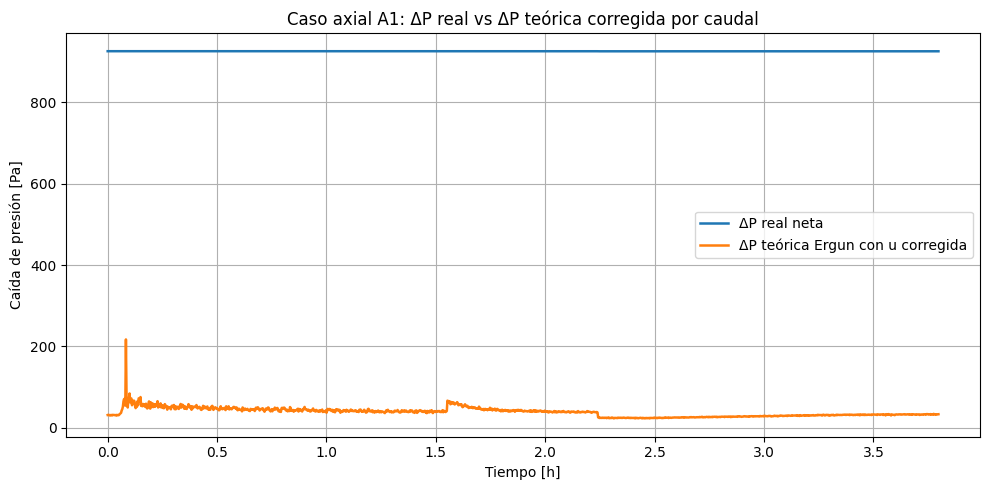

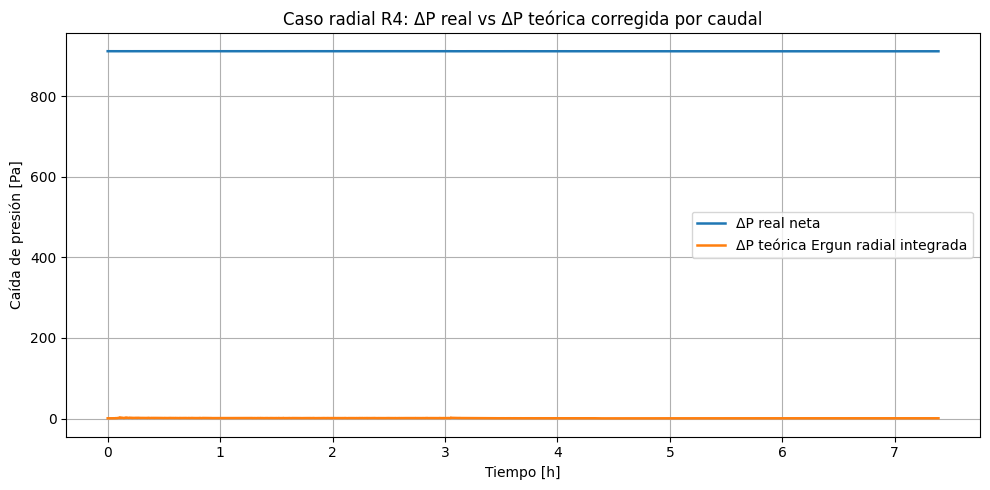

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI

# =========================
# Cargar datasets
# =========================

df_axial = pd.read_excel(BASE / "A1_axial_calibrado.xlsx")
df_radial = pd.read_excel(BASE / "R4_radial_calibrado.xlsx")

# =========================
# Parámetros generales
# =========================

P_atm = 101325  # Pa
D_p = 0.02      # m

e_axial = 0.46
e_radial = 0.63

# Ducto de medición: 2 in de diámetro
D_ducto = 2 * 0.0254  # m
A_ducto = np.pi * (D_ducto / 2)**2

# =========================
# Geometría axial
# =========================

D_axial = 0.280  # m
L_axial = 0.551  # m
A_axial = np.pi * (D_axial / 2)**2

# =========================
# Geometría radial
# =========================

D_outer_radial = 0.240  # m
D_inner_radial = 0.060  # m
H_radial = 0.256        # m

R_outer = D_outer_radial / 2
R_inner = D_inner_radial / 2

# =========================
# Temperatura promedio interna
# =========================

cols_axial_bed = [f"T{i}" for i in range(1, 9)]
cols_radial_bed = [f"T{i}" for i in range(1, 19)]

df_axial["T_ref_C"] = df_axial[cols_axial_bed].mean(axis=1)
df_radial["T_ref_C"] = df_radial[cols_radial_bed].mean(axis=1)

# =========================
# Propiedades del aire
# =========================

def air_props(T_C):
    T_K = T_C + 273.15
    rho_air = PropsSI("D", "T", T_K, "P", P_atm, "Air")  # kg/m3
    mu_air  = PropsSI("V", "T", T_K, "P", P_atm, "Air")  # Pa*s
    return rho_air, mu_air

# =========================
# Ergun axial con igualdad de caudales
# =========================

def calcular_dP_axial(df):
    dP_list = []
    u_lecho_list = []
    Q_list = []
    rho_list = []
    mu_list = []

    for i in range(len(df)):
        T_C = df.loc[i, "T_ref_C"]
        rho_air, mu_air = air_props(T_C)

        # Velocidad medida en ducto
        u_ducto = df.loc[i, "u_air_m_s"]

        # Igualdad de caudales volumétricos
        Q = u_ducto * A_ducto

        # Velocidad superficial real en el lecho axial
        u_lecho = Q / A_axial

        dP_dL = (
            150 * mu_air * (1 - e_axial)**2 * u_lecho / (D_p**2 * e_axial**3)
            + 1.75 * rho_air * (1 - e_axial) * u_lecho**2 / (D_p * e_axial**3)
        )

        dP = L_axial * dP_dL

        dP_list.append(dP)
        u_lecho_list.append(u_lecho)
        Q_list.append(Q)
        rho_list.append(rho_air)
        mu_list.append(mu_air)

    df["Q_m3_s"] = Q_list
    df["u_lecho_m_s"] = u_lecho_list
    df["rho_air"] = rho_list
    df["mu_air"] = mu_list
    df["dP_ergun_Pa"] = dP_list

    return df

# =========================
# Ergun radial integrado con área variable
# =========================

def calcular_dP_radial_integrado(df):
    dP_list = []
    Q_list = []
    u_inner_list = []
    u_outer_list = []
    u_mean_list = []
    rho_list = []
    mu_list = []

    for i in range(len(df)):
        T_C = df.loc[i, "T_ref_C"]
        rho_air, mu_air = air_props(T_C)

        # Velocidad medida en ducto
        u_ducto = df.loc[i, "u_air_m_s"]

        # Igualdad de caudales volumétricos
        Q = u_ducto * A_ducto

        # En radial, el área cambia con el radio:
        # A(r) = 2*pi*r*H
        # u(r) = Q / A(r)

        u_inner = Q / (2 * np.pi * R_inner * H_radial)
        u_outer = Q / (2 * np.pi * R_outer * H_radial)
        r_mean = (R_inner + R_outer) / 2
        u_mean = Q / (2 * np.pi * r_mean * H_radial)

        # Coeficientes de Ergun
        C1 = 150 * mu_air * (1 - e_radial)**2 / (D_p**2 * e_radial**3)
        C2 = 1.75 * rho_air * (1 - e_radial) / (D_p * e_radial**3)

        # Integración analítica:
        # dP = ∫[C1*u(r) + C2*u(r)^2] dr
        # con u(r) = Q/(2*pi*r*H)
        K = Q / (2 * np.pi * H_radial)

        dP = (
            C1 * K * np.log(R_outer / R_inner)
            + C2 * K**2 * (1 / R_inner - 1 / R_outer)
        )

        dP_list.append(dP)
        Q_list.append(Q)
        u_inner_list.append(u_inner)
        u_outer_list.append(u_outer)
        u_mean_list.append(u_mean)
        rho_list.append(rho_air)
        mu_list.append(mu_air)

    df["Q_m3_s"] = Q_list
    df["u_inner_m_s"] = u_inner_list
    df["u_outer_m_s"] = u_outer_list
    df["u_mean_radial_m_s"] = u_mean_list
    df["rho_air"] = rho_list
    df["mu_air"] = mu_list
    df["dP_ergun_Pa"] = dP_list

    return df



df_axial = calcular_dP_axial(df_axial)
df_radial = calcular_dP_radial_integrado(df_radial)



plt.figure(figsize=(10, 5))

plt.plot(
    df_axial["t_h"],
    df_axial["dP_net_Pa"],
    label="ΔP real neta",
    linewidth=1.8
)

plt.plot(
    df_axial["t_h"],
    df_axial["dP_ergun_Pa"],
    label="ΔP teórica Ergun con u corregida",
    linewidth=1.8
)

plt.xlabel("Tiempo [h]")
plt.ylabel("Caída de presión [Pa]")
plt.title("Caso axial A1: ΔP real vs ΔP teórica corregida por caudal")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 5))

plt.plot(
    df_radial["t_h"],
    df_radial["dP_net_Pa"],
    label="ΔP real neta",
    linewidth=1.8
)

plt.plot(
    df_radial["t_h"],
    df_radial["dP_ergun_Pa"],
    label="ΔP teórica Ergun radial integrada",
    linewidth=1.8
)

plt.xlabel("Tiempo [h]")
plt.ylabel("Caída de presión [Pa]")
plt.title("Caso radial R4: ΔP real vs ΔP teórica corregida por caudal")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



df_axial.to_excel(BASE / "A1_axial_ergun_caudal_corregido.xlsx", index=False)
df_radial.to_excel(BASE / "R4_radial_ergun_caudal_corregido.xlsx", index=False)